## 1. Compare Portfolios

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
spy_returns = pd.read_csv('data/spy_returns.csv', index_col = 0, parse_dates = True).reindex(t_eval)
benchmark = (1 + spy_returns.reindex(t_eval)).cumprod()

In [33]:
factor_returns = pd.read_csv('outputs/factor_returns.csv', index_col = 0, parse_dates = True)
ra_returns = pd.read_csv('outputs/ra_returns.csv', index_col = 0, parse_dates = True)



factor_portfolio = (1 + factor_returns).cumprod()
ra_portfolio = (1 + ra_returns).cumprod()


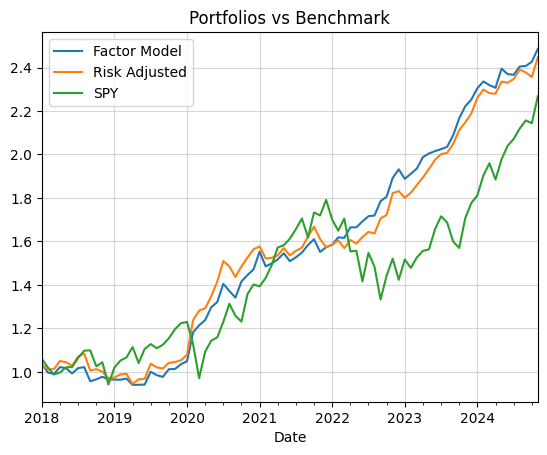

In [34]:
fig, ax = plt.subplots()

factor_portfolio.squeeze().plot(ax=ax, label='Factor Model')
ra_portfolio.squeeze().plot(ax=ax, label='Risk Adjusted')
benchmark.plot(ax=ax, label='Benchmark')

ax.set_title('Portfolios vs Benchmark')
ax.grid(alpha=0.5)
ax.legend()

plt.savefig("outputs/Portfolios_vs_Benchmark.png")

In [48]:
mvo_returns = np.load('outputs/mvo_returns_lambda.npy', allow_pickle = True).item()

mvo_portfolios = {}
for lam in [0.01,0.03,0.1,0.3,1,3,10,30]:
    mvo_portfolios[lam] = (1 + mvo_returns[lam]).cumprod()



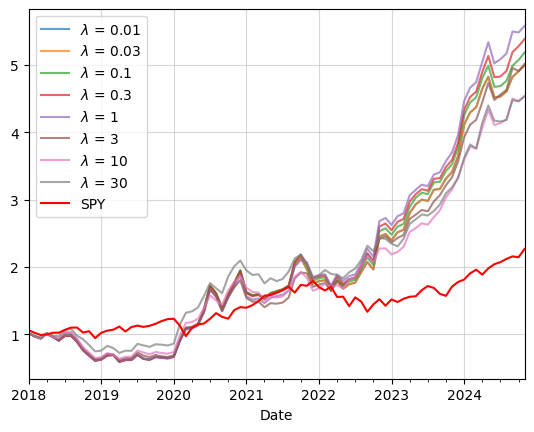

In [56]:
fig, ax = plt.subplots()

for lam in [0.01,0.03,0.1,0.3,1,3,10,30]:
    mvo_portfolios[lam].plot(ax = ax, alpha = 0.7, label = rf'$\lambda$ = {lam}')

benchmark.plot(ax=ax, color = 'r', label='Benchmark')
ax.legend()
ax.grid(alpha = 0.5)

## 2. Portfolio Analytics

In [63]:
def analyse_portfolio(portfolio_returns, outs = False):

    if isinstance(portfolio_returns, pd.Series):
        portfolio_returns = portfolio_returns.to_frame()
        
    mean = portfolio_returns.mean().item()
    std = portfolio_returns.std().item()
    sharpe = np.sqrt(12) * mean / std

    portfolio = (1 + portfolio_returns).cumprod()
    total_return = portfolio.iloc[-1].item() - 1
    annual_return = (1 + total_return) ** (12 / len(portfolio)) - 1
    running_max = portfolio.cummax()
    drawdown = portfolio / running_max - 1
    max_dd = drawdown.min().item()

    if outs:
        return mean, std, sharpe, total_return, annual_return, max_dd
    
    else:
        print(f"Mean Return: {mean * 100:.2f}%")
        print(f"Mean Std: {std * 100:.2f}%")
        print(f"Sharpe Ratio: {sharpe:.2f}")
        print(f"Total Returns: {total_return * 100:.0f}%")
        print(f"Annual Return: {annual_return * 100:.0f}%")
        print(f"Max drawdown: {max_dd * 100:.0f}%")

    


## 3. Efficient Frontier

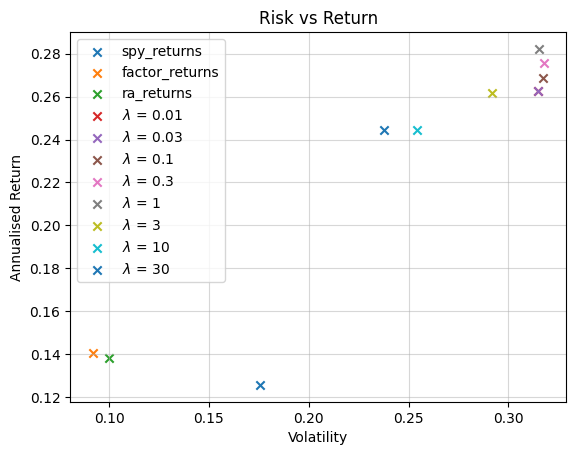

In [64]:

portfolios = [spy_returns, factor_returns, ra_returns]
labels = ['spy_returns', 'factor_returns', 'ra_returns']

fig, ax = plt.subplots()

for returns, label in zip(portfolios, labels):
    _, std, _, _, ann, _ = analyse_portfolio(returns, outs = True)
    ax.scatter(np.sqrt(12) * std, ann, marker = 'x', label = label)

for lam in [0.01,0.03,0.1,0.3,1,3,10,30]:
    _, std, _, _, ann, _ = analyse_portfolio(mvo_returns[lam], outs = True)
    ax.scatter(np.sqrt(12) * std, ann, marker = 'x', label = rf'$\lambda$ = {lam}')


ax.set_xlabel('Volatility')
ax.set_ylabel('Annualised Return')
ax.set_title('Risk vs Return')
ax.grid(alpha = 0.5)
ax.legend()